In [1]:
# Cell 1 – Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings("ignore")

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

CELL_COL = "CO_DN"
RAW_FILE = "../data/4G raw KPI Cell wise17th_June'26.xlsb"

def short_cell_name(co_dn):
    parts = str(co_dn).split("/")
    if len(parts) >= 2:
        return f"{parts[-2]}_{parts[-1]}"
    return str(co_dn)

KPI_COLS = [
    "ERAB Drop Rate_Radio_Nokia_VeMr",
    "E2E Call Setup Success Rate_Nokia_VeMr",
    "VoLTE Call Setup Success Rate_Nokia_VeMr",
    "Average CQI_Nokia_VeMr",
    "Nokia_LTE_DL_User_Throughput_Mbps",
]

CONTAMINATION = 0.05
print("✅ Imports done")

✅ Imports done


In [2]:
# Cell 2 – Load data and build cell-level feature matrix
import pyxlsb

df = pd.read_csv("../data/cleaned_master_data.csv")
if "Short_Cell" not in df.columns:
    df["Short_Cell"] = df[CELL_COL].apply(short_cell_name)

kpi_present = [c for c in KPI_COLS if c in df.columns]
for col in kpi_present:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Cell-level aggregation — one row per unique cell
cell_features = df.groupby("Short_Cell")[kpi_present].agg([
    "mean", "std", "min", "max"
]).reset_index()

cell_features.columns = [
    f"{col}_{stat}" if stat else col
    for col, stat in cell_features.columns
]

feature_cols = [c for c in cell_features.columns if c != "Short_Cell"]
X_raw        = cell_features[feature_cols].fillna(
    cell_features[feature_cols].median()
)

# RobustScaler — handles telecom outliers better than StandardScaler
X = RobustScaler().fit_transform(X_raw)

print(f"Feature matrix : {X.shape}")
print(f"Cells          : {len(cell_features)}")
print(f"Features       : {len(feature_cols)}")

Feature matrix : (51359, 20)
Cells          : 51359
Features       : 20


In [3]:

# Cell 3 – Train and compare 3 anomaly detection models

models = {
    "Isolation Forest": IsolationForest(
        n_estimators  = 200,
        contamination = CONTAMINATION,
        random_state  = 42,
        n_jobs        = -1
    ),
    "One-Class SVM": OneClassSVM(
        kernel = "rbf",
        nu     = CONTAMINATION,
        gamma  = "scale"
    ),
    "LOF": LocalOutlierFactor(
        n_neighbors  = 20,
        contamination= CONTAMINATION,
        novelty      = True
    ),
}

results      = []
predictions  = {}

for name, model in models.items():
    start = time.time()
    model.fit(X)
    preds   = model.predict(X)
    elapsed = round(time.time() - start, 3)

    n_outliers = (preds == -1).sum()

    try:
        sil = round(silhouette_score(X, preds, sample_size=300, random_state=42), 4)
    except:
        sil = None

    try:
        db = round(davies_bouldin_score(X, preds), 4)
    except:
        db = None

    predictions[name] = preds
    results.append({
        "Model"          : name,
        "Outliers Found" : n_outliers,
        "Outlier %"      : f"{n_outliers/len(X)*100:.1f}%",
        "Silhouette ↑"   : sil,
        "Davies-Bouldin ↓": db,
        "Time (s)"       : elapsed,
    })
    print(f"  {name:<22} outliers={n_outliers}  "
          f"silhouette={sil}  db={db}  time={elapsed}s")

comparison_df = pd.DataFrame(results)
print("\n")
print(comparison_df.to_string(index=False))

  Isolation Forest       outliers=2568  silhouette=0.8619  db=1.7863  time=1.075s
  One-Class SVM          outliers=2570  silhouette=0.8582  db=1.7875  time=24.047s
  LOF                    outliers=2179  silhouette=0.7295  db=2.8569  time=8.077s


           Model  Outliers Found Outlier %  Silhouette ↑  Davies-Bouldin ↓  Time (s)
Isolation Forest            2568      5.0%        0.8619            1.7863     1.075
   One-Class SVM            2570      5.0%        0.8582            1.7875    24.047
             LOF            2179      4.2%        0.7295            2.8569     8.077


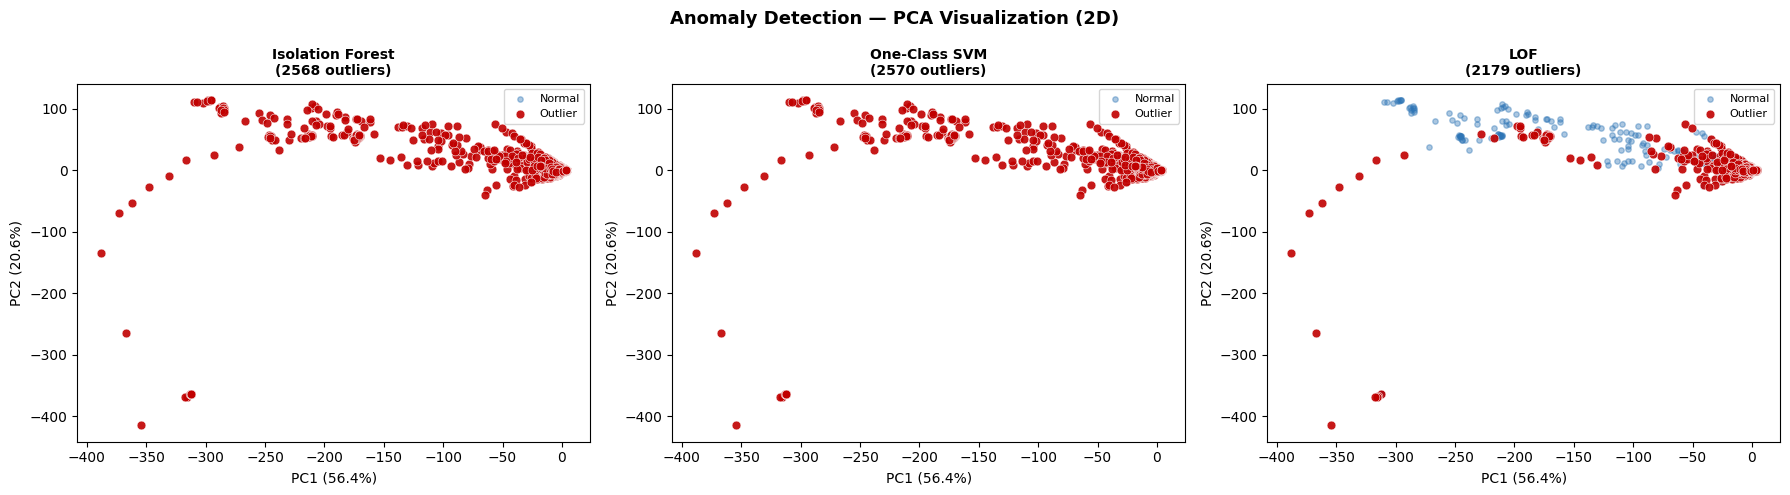

✅ Saved → outputs/model_comparison_pca.png


In [4]:
# Cell 4 – Visualize all 3 models in 2D using PCA

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var   = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Anomaly Detection — PCA Visualization (2D)",
             fontsize=13, fontweight="bold")

for ax, (name, preds) in zip(axes, predictions.items()):
    normal  = preds ==  1
    outlier = preds == -1
    ax.scatter(X_pca[normal,  0], X_pca[normal,  1],
               c="#2E75B6", alpha=0.4, s=15, label="Normal")
    ax.scatter(X_pca[outlier, 0], X_pca[outlier, 1],
               c="#C00000", alpha=0.9, s=40, label="Outlier",
               zorder=5, edgecolors="white", linewidth=0.4)
    ax.set_title(f"{name}\n({(preds==-1).sum()} outliers)",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/model_comparison_pca.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/model_comparison_pca.png")

In [5]:
# Cell 5 – Ensemble: flag cell only if 2+ models agree

pred_matrix = pd.DataFrame({
    name: (preds == -1).astype(int)
    for name, preds in predictions.items()
})
pred_matrix["Short_Cell"]  = cell_features["Short_Cell"].values
pred_matrix["vote_count"]  = pred_matrix[list(predictions.keys())].sum(axis=1)
pred_matrix["ensemble"]    = (pred_matrix["vote_count"] >= 2).astype(int)

print("Ensemble Agreement:\n")
print(f"  Any 1 model  : {(pred_matrix['vote_count'] >= 1).sum()} cells")
print(f"  2+ models    : {(pred_matrix['vote_count'] >= 2).sum()} cells")
print(f"  All 3 models : {(pred_matrix['vote_count'] == 3).sum()} cells")

# Save ensemble results
ensemble_out = pred_matrix[pred_matrix["ensemble"] == 1][[
    "Short_Cell", "vote_count"
] + list(predictions.keys())].copy()
ensemble_out["Confidence"] = ensemble_out["vote_count"].map({
    3: "High — all 3 models agree",
    2: "Medium — 2 models agree",
    1: "Low — 1 model only",
})
ensemble_out.to_csv("../outputs/ensemble_anomalies.csv", index=False)
print(f"\n✅ Saved → outputs/ensemble_anomalies.csv")
print(f"   {len(ensemble_out)} cells flagged by ensemble (2+ models)")

Ensemble Agreement:

  Any 1 model  : 4682 cells
  2+ models    : 2067 cells
  All 3 models : 568 cells

✅ Saved → outputs/ensemble_anomalies.csv
   2067 cells flagged by ensemble (2+ models)


In [6]:
# Cell 6 – Print comparison summary

print("=" * 55)
print("MODEL COMPARISON SUMMARY")
print("=" * 55)
print(comparison_df.to_string(index=False))

best_sil = comparison_df.loc[
    comparison_df["Silhouette ↑"].apply(
        lambda x: x if x is not None else -999
    ).idxmax(), "Model"
]
best_db = comparison_df.loc[
    comparison_df["Davies-Bouldin ↓"].apply(
        lambda x: x if x is not None else 999
    ).idxmin(), "Model"
]
print(f"\n  Best Silhouette Score : {best_sil}")
print(f"  Best Davies-Bouldin  : {best_db}")
print(f"\n  Ensemble anomalies   : {len(ensemble_out)}")
print(f"  (cells flagged by 2+ models)")

MODEL COMPARISON SUMMARY
           Model  Outliers Found Outlier %  Silhouette ↑  Davies-Bouldin ↓  Time (s)
Isolation Forest            2568      5.0%        0.8619            1.7863     1.075
   One-Class SVM            2570      5.0%        0.8582            1.7875    24.047
             LOF            2179      4.2%        0.7295            2.8569     8.077

  Best Silhouette Score : Isolation Forest
  Best Davies-Bouldin  : Isolation Forest

  Ensemble anomalies   : 2067
  (cells flagged by 2+ models)
